# QAP — Quadratic Assignment Problem

El **QAP** tiene una intuición física muy limpia: tienes **n instalaciones (bodegas)** que debes colocar en **n ubicaciones (localizaciones)**, una en cada una. Entre las bodegas circula un **flujo** (personas, materiales, datos) y entre las ubicaciones hay una **distancia**. La idea es colocar las bodegas de forma que los pares que más se comunican queden lo más cerca posible.

## Los dos datos del problema

- **Localizaciones** → matriz de **distancia** $D$ (dato fijo)
- **Bodegas** → matriz de **flujo** $F$ (dato fijo)

Ni el flujo ni la distancia se optimizan: son datos. Lo único que se decide es la **asignación** (qué bodega va en qué ubicación), representada por una permutación $\pi$.

## Función objetivo

$$Z(\pi) = \sum_{i=1}^{n}\sum_{j=1}^{n} f_{ij}\cdot d_{\pi(i)\,\pi(j)}$$

Para cada par de bodegas $(i, j)$ se toma su flujo $f_{ij}$ y se multiplica por la distancia entre las ubicaciones donde quedaron colocadas, $d_{\pi(i)\pi(j)}$. Es **cuadrática** porque cada término depende de *dos* decisiones de asignación a la vez.

## 26 de Junio — QAP Operadores

- **Mío:** La idea es asignar ubicaciones a las bodegas de tal forma que la distancia entre bodegas sea mínima y el flujo sea máximo.
- **Corregido:** Asignar cada bodega a una ubicación de modo que se **minimice la suma total de flujo × distancia**, lo que en la práctica significa colocar las bodegas que más se comunican (mayor flujo) en las ubicaciones más cercanas entre sí.
- **Nota clave:** El flujo no se maximiza — es un peso fijo que hace que una distancia "cuente" más o menos en el costo. Solo se minimiza el producto acumulado.

## La solución: una permutación π

Una solución del QAP es una **permutación** $\pi$: simplemente un arreglo que dice, para cada bodega, en qué ubicación quedó.

$$\pi = [\,3,\ 2,\ 1\,]$$

Se lee por posición: la **posición** es la bodega, el **valor** es la ubicación.

| Bodega $i$ | $\pi(i)$ = ubicación |
|:---:|:---:|
| 1 | 3 |
| 2 | 2 |
| 3 | 1 |

Es decir: bodega 1 → ubicación 3, bodega 2 → ubicación 2, bodega 3 → ubicación 1.

## Cómo se recupera $d_{\pi(i)\,\pi(j)}$

El término $d_{\pi(i)\pi(j)}$ es la distancia entre las ubicaciones **donde quedaron** las bodegas $i$ y $j$. Se obtiene en dos pasos: primero se consulta $\pi$ para saber las ubicaciones, y con esas ubicaciones se entra a la matriz $D$.

Ejemplo con el par de bodegas $(i=1,\ j=2)$ y $\pi = [3,2,1]$:

$$d_{\pi(1)\,\pi(2)} = d_{3,\,2}$$

porque $\pi(1)=3$ y $\pi(2)=2$. Ese valor se lee en la fila 3, columna 2 de $D$:

$$D=\begin{bmatrix} 0 & 2 & 3 \\ 2 & 0 & 1 \\ 3 & 1 & 0 \end{bmatrix} \quad\Rightarrow\quad d_{3,2}=1$$

Y el término completo de ese par es $f_{12}\cdot d_{3,2} = 3 \cdot 1 = 3$.

## En Python (ojo con el índice base 0)

En la matemática los índices van de 1 a n, pero en Python/NumPy van de 0 a n−1, así que se resta 1 al indexar:

```python
import numpy as np

F  = np.array([[0,3,1],[3,0,2],[1,2,0]])   # flujo entre bodegas
D  = np.array([[0,2,3],[2,0,1],[3,1,0]])   # distancia entre ubicaciones
pi = np.array([3, 2, 1])                    # permutación (notación 1-indexada)

i, j = 1, 2                                 # bodegas (1-indexadas)
# pi[i-1] = ubicación de la bodega i ;  -1 de nuevo para indexar D
d = D[pi[i-1]-1, pi[j-1]-1]                 # -> d_{3,2} = 1
termino = F[i-1, j-1] * d                   # -> 3 * 1 = 3
```

> **Tip de implementación:** muchas implementaciones guardan `pi` directamente en base 0 (valores de 0 a n−1) para evitar los `-1` repetidos. La función objetivo queda más limpia:
> ```python
> Z = sum(F[i, j] * D[pi[i], pi[j]] for i in range(n) for j in range(n))
> ```

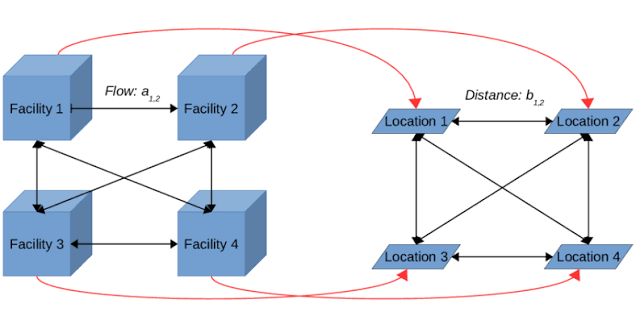

## Bloque 1 — Configuración e importaciones

**Configuración del experimento.** En este bloque definimos las librerías base, fijamos la semilla para reproducibilidad y registramos los metadatos de las instancias: su tamaño n y la mejor solución conocida (BKS) entregada en el enunciado. La BKS la usaremos después para calcular el GAP. También fijamos N_RUNS = 7, el número de ejecuciones independientes por cada combinación (operador × instancia), necesario porque la Búsqueda Tabú parte de una solución inicial aleatoria y es un método estocástico: con varias corridas podremos reportar promedio, desviación y mejor valor.

In [1]:
PATH = "/content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Instances"

In [2]:
import numpy as np
import time
from pathlib import Path
from dataclasses import dataclass

# --- Reproducibilidad ---
SEED_BASE = 42  # cada corrida r usará la semilla SEED_BASE + r

# --- Número de ejecuciones independientes por (operador x instancia) ---
N_RUNS = 7

# --- Ubicación de los archivos .dat de QAPLIB ---
INSTANCES_DIR = Path(PATH)  # ajusta a tu ruta local

# --- Metadata de las instancias: nombre -> (n, mejor solución conocida) ---
INSTANCES = {
    "bur26c":  {"n": 26,  "bks": 5_426_795},
    "esc32h":  {"n": 32,  "bks": 438},
    "esc64a":  {"n": 64,  "bks": 116},
    "lipa60a": {"n": 60,  "bks": 107_218},
    "tai80a":  {"n": 80,  "bks": 13_499_184},
    "tai80b":  {"n": 80,  "bks": 818_415_043},
}

print(f"Instancias configuradas: {list(INSTANCES.keys())}")
print(f"Corridas por configuración: {N_RUNS}")
print(f"Semilla base: {SEED_BASE}")

Instancias configuradas: ['bur26c', 'esc32h', 'esc64a', 'lipa60a', 'tai80a', 'tai80b']
Corridas por configuración: 7
Semilla base: 42


## Bloque 2 — Lector de instancias QAPLIB

**Lectura del archivo .dat.** Cada instancia de QAPLIB viene en un archivo .dat con un formato simple pero con un detalle importante: en la primera línea aparece el tamaño n, y luego vienen dos matrices de n×n —por convención, la primera es la matriz de flujo F (entre instalaciones) y la segunda es la matriz de distancia D (entre ubicaciones)—. El detalle clave es que los números de cada matriz pueden estar repartidos en varias líneas y no necesariamente n por fila; por eso no leemos línea por línea, sino que tomamos TODOS los números separados por espacios y los repartimos en orden: el primero es n, los siguientes n×n son F y los últimos n×n son D. Esto hace el lector robusto frente a cualquier variación de formato. Devolvemos la instancia como un objeto estructurado (QAPInstance) que incluye n, las matrices y la mejor solución conocida (BKS) que registramos en el Bloque 1.

In [3]:
@dataclass
class QAPInstance:
    name: str
    n: int
    F: np.ndarray   # matriz de flujo (n x n)
    D: np.ndarray   # matriz de distancia (n x n)
    bks: int        # mejor solución conocida (best known solution)


def read_qaplib(path: Path) -> tuple[int, np.ndarray, np.ndarray]:
    """Lee un archivo .dat de QAPLIB y devuelve (n, F, D).

    Estrategia robusta: se ignoran los saltos de línea y se toman todos
    los tokens numéricos en orden -> n, luego n*n para F, luego n*n para D.
    """
    tokens = Path(path).read_text().split()      # todos los números, sin importar las líneas
    nums = [int(t) for t in tokens]              # las instancias dadas son enteras

    n = nums[0]
    #2*26*26 = Largo del array
    resto = nums[1:]


    esperado = 2 * n * n
    if len(resto) < esperado:
        raise ValueError(
            f"{path.name}: se esperaban {esperado} valores para las matrices, "
            f"se encontraron {len(resto)}."
        )

    # De: 1 hasta: 676 Largo: 676 Reshape= (26,26)
    F = np.array(resto[:n*n],        dtype=np.int64).reshape(n, n)
    # De: 676 hasta: 1352 Largo: 676 Reshape= (26,26)
    D = np.array(resto[n*n:2*n*n],   dtype=np.int64).reshape(n, n)
    return n, F, D


def load_instance(name: str) -> QAPInstance:
    """Carga una instancia por nombre usando la metadata del Bloque 1."""
    meta = INSTANCES[name]
    path = INSTANCES_DIR / f"{name}.dat"
    n, F, D = read_qaplib(path)

    # Verificación de coherencia con la metadata declarada
    assert n == meta["n"], f"{name}: n leído ({n}) != n esperado ({meta['n']})"

    return QAPInstance(name=name, n=n, F=F, D=D, bks=meta["bks"])


# --- Prueba rápida (ajusta INSTANCES_DIR si es necesario) ---
try:
    inst = load_instance("bur26c")
    print(f"Instancia: {inst.name}")
    print(f"  n          = {inst.n}")
    print(f"  F shape    = {inst.F.shape}, D shape = {inst.D.shape}")
    print(f"  BKS        = {inst.bks:,}")
    print(f"  F[0,:5]    = {inst.F[0, :5]}")
    print(f"  D[0,:5]    = {inst.D[0, :5]}")
except FileNotFoundError:
    print("No se encontró el .dat — coloca los archivos en INSTANCES_DIR y reejecuta.")

Instancia: bur26c
  n          = 26
  F shape    = (26, 26), D shape = (26, 26)
  BKS        = 5,426,795
  F[0,:5]    = [53 66 66 66 66]
  D[0,:5]    = [  4 224 348 391  18]


## Bloque 3 — Función objetivo

**Cálculo del costo de una permutación.** Aquí implementamos la función objetivo del QAP, que evalúa qué tan buena es una asignación. Dada una permutación p (donde p[i] es la ubicación asignada a la instalación i), el costo es la suma, sobre todos los pares de instalaciones (i, j), del producto entre su flujo F[i, j] y la distancia D[p[i], p[j]] entre las ubicaciones asignadas. Lo implementamos de forma vectorizada con NumPy: en lugar de un doble bucle O(n²) lento, construimos la matriz de distancias reordenada según la permutación (D[p][:, p]) y la multiplicamos elemento a elemento con F, sumando todo. Esta función nos sirve para dos cosas: validar nuestra implementación calculando el costo de la mejor solución conocida (debería dar exactamente la BKS), y como base de referencia para verificar más adelante la evaluación incremental (delta) del swap.

Fancy Indexing: https://jakevdp.github.io/PythonDataScienceHandbook/02.07-fancy-indexing.html

In [4]:
def objective(perm: np.ndarray, F: np.ndarray, D: np.ndarray) -> int:
    """Costo QAP de una permutación: sum_{i,j} F[i,j] * D[perm[i], perm[j]].

    Vectorizado: D_perm = D reordenada por filas y columnas según perm.
    """
    # D[row][colum]
    # D[perm]  ≡  "tráeme las filas de D en este orden: 2, 0, 3, 1"
    # D[:, perm]  ≡  "de cada fila, tráeme las columnas en este orden: 2, 0, 3, 1"

    D_perm = D[perm][:, perm]
    #  F[a][b] y D_perm[a][b] hablan del mismo par de instalaciones, en la misma casilla.
    return int(np.sum(F * D_perm))     # producto elemento a elemento y suma total


# --- Validación: ¿el costo de una solución óptima conocida reproduce la BKS? ---
# Cargamos la permutación óptima desde el .sln de QAPLIB, si está disponible.
def read_qaplib_solution(path: Path) -> np.ndarray:
    """Lee un .sln de QAPLIB: primera fila (n, costo), luego la permutación.

    La permutación en QAPLIB es base-1; la convertimos a base-0 para NumPy.
    """
    nums = [int(t) for t in Path(path).read_text().split()]
    n = nums[0]
    perm_1 = nums[2:2 + n]             # se omite nums[1] (el costo)
    return np.array(perm_1, dtype=np.int64) - 1   # a base-0


# Prueba de validación con bur26c
inst = load_instance("bur26c")
sln_path = INSTANCES_DIR / "bur26c.sln"

try:
    perm_opt = read_qaplib_solution(sln_path)
    costo = objective(perm_opt, inst.F, inst.D)
    print(f"Costo calculado : {costo:,}")
    print(f"BKS esperada    : {inst.bks:,}")
    print("✓ COINCIDE" if costo == inst.bks else "✗ NO coincide — revisar convención F/D o base 0/1")
except FileNotFoundError:
    # Si no tienes el .sln, validamos al menos que una permutación aleatoria corre sin error
    rng = np.random.default_rng(SEED_BASE)
    perm_rand = rng.permutation(inst.n)
    print("No se encontró .sln. Prueba con permutación aleatoria:")
    print(f" Permutacion = {perm_rand} ")
    print(f"  Costo aleatorio = {objective(perm_rand, inst.F, inst.D):,}")
    print(f"  BKS (referencia)= {inst.bks:,}")

No se encontró .sln. Prueba con permutación aleatoria:
 Permutacion = [ 7 15 21 20 17  5 18 25 10  9  6 16  3  0 22 19 12 11 14 24  2  4 23  1
 13  8] 
  Costo aleatorio = 6,011,696
  BKS (referencia)= 5,426,795


## Bloque 3b — Validación de la función objetivo (sin .sln)

**Validación por consistencia interna.** Como no disponemos de las permutaciones óptimas (.sln), no podemos reproducir la BKS exacta directamente. En su lugar validamos que la función objetivo esté bien implementada comparándola con una versión "ingenua" de doble bucle, que es lenta pero transparente y difícil de equivocar. Si ambas dan el mismo costo para muchas permutaciones aleatorias, confiamos en la versión vectorizada (que es la que usaremos por velocidad). La verificación contra el óptimo conocido (BKS) ocurrirá de forma indirecta más adelante: ningún resultado de la Búsqueda Tabú debería ser MENOR que la BKS; si lo fuera, indicaría un error en la evaluación.

In [5]:
def objective_naive(perm: np.ndarray, F: np.ndarray, D: np.ndarray) -> int:
    """Versión de referencia con doble bucle (lenta pero transparente)."""
    n = len(perm)
    total = 0
    for i in range(n):
        for j in range(n):
            total += F[i, j] * D[perm[i], perm[j]]
    return int(total)


# --- Validación cruzada: vectorizada vs. ingenua, en varias instancias ---
rng = np.random.default_rng(SEED_BASE)
todo_ok = True

for name in INSTANCES:
    inst = load_instance(name)
    for _ in range(5):  # 5 permutaciones aleatorias por instancia
        perm = rng.permutation(inst.n)
        c_vec = objective(perm, inst.F, inst.D)
        c_naive = objective_naive(perm, inst.F, inst.D)
        if c_vec != c_naive:
            todo_ok = False
            print(f"✗ {name}: discrepancia {c_vec:,} vs {c_naive:,}")

    # Referencia: costo de una permutación aleatoria vs. el óptimo conocido
    perm = rng.permutation(inst.n)
    c = objective(perm, inst.F, inst.D)
    print(f"{name:8s}  aleatorio={c:>15,}   BKS={inst.bks:>15,}   "
          f"(aleatorio es {c/inst.bks:.1f}x la BKS)")

print()
print("✓ Función objetivo validada (vectorizada == ingenua)" if todo_ok
      else "✗ HAY DISCREPANCIAS — revisar")

bur26c    aleatorio=      5,908,673   BKS=      5,426,795   (aleatorio es 1.1x la BKS)
esc32h    aleatorio=            690   BKS=            438   (aleatorio es 1.6x la BKS)
esc64a    aleatorio=            288   BKS=            116   (aleatorio es 2.5x la BKS)
lipa60a   aleatorio=        110,164   BKS=        107,218   (aleatorio es 1.0x la BKS)
tai80a    aleatorio=     15,696,536   BKS=     13,499,184   (aleatorio es 1.2x la BKS)
tai80b    aleatorio=  1,281,003,857   BKS=    818,415,043   (aleatorio es 1.6x la BKS)

✓ Función objetivo validada (vectorizada == ingenua)


## Bloque 4 — Solución inicial y operador swap (con evaluación delta)

**El primer operador: intercambio (swap).** Aquí construimos dos piezas. Primero, la generación de una solución inicial aleatoria (una permutación al azar), que será el punto de partida de cada corrida de la Búsqueda Tabú. Segundo, el operador swap y su evaluación incremental (delta), que es la pieza clave de eficiencia del QAP. En lugar de recalcular toda la función objetivo O(n²) cada vez que probamos intercambiar dos posiciones r y s, calculamos solo la VARIACIÓN del costo que produce ese intercambio. Para matrices asimétricas (el caso general, que cubre bur, lipa-a y tai-b), esa variación se calcula recorriendo una sola vez los demás elementos, en O(n) por movimiento. Esto permite evaluar todo el vecindario de swap en O(n²) en vez de O(n³), una diferencia enorme en las instancias grandes. Validamos el delta comparándolo contra la diferencia real de la función objetivo: deben coincidir exactamente.

In [12]:
def initial_solution(n: int, rng: np.random.Generator) -> np.ndarray:
    """Genera una permutación inicial aleatoria de tamaño n."""
    return rng.permutation(n)


def swap_delta(perm: np.ndarray, F: np.ndarray, D: np.ndarray, r: int, s: int) -> int:
    """Variación del costo al intercambiar las posiciones r y s (caso general/asimétrico).

    Devuelve f(perm') - f(perm), donde perm' tiene perm[r] y perm[s] intercambiados.
    Costo O(n) en lugar de recalcular toda la función objetivo.
    """
    print(f"{perm}")
    pr, ps = perm[r], perm[s]
    print(f"valor posicion {r}: {pr} - valor posicion {s}: {ps}")
    delta = 0

    # Contribución de los términos donde interviene r o s frente a un tercero k
    for k in range(len(perm)):
        if k == r or k == s:
            continue
        pk = perm[k]
        delta += (
            F[r, k] * (D[ps, pk] - D[pr, pk]) +
            F[s, k] * (D[pr, pk] - D[ps, pk]) +
            F[k, r] * (D[pk, ps] - D[pk, pr]) +
            F[k, s] * (D[pk, pr] - D[pk, ps])
        )

    # Términos directos entre r y s (incluye diagonales por generalidad)
    delta += (
        F[r, s] * (D[ps, pr] - D[pr, ps]) +
        F[s, r] * (D[pr, ps] - D[ps, pr]) +
        F[r, r] * (D[ps, ps] - D[pr, pr]) +
        F[s, s] * (D[pr, pr] - D[ps, ps])
    )
    return int(delta)


# --- Validación del delta contra la diferencia real de la función objetivo ---
inst = load_instance("bur26c")  # asimétrica: el mejor caso para probar el delta
rng = np.random.default_rng(SEED_BASE)

ok = True
iterations = 1
for _ in range(iterations):
    perm = rng.permutation(inst.n)
    r, s = rng.choice(inst.n, size=2, replace=False)

    delta = swap_delta(perm, inst.F, inst.D, r, s)

    perm2 = perm.copy()
    perm2[r], perm2[s] = perm2[s], perm2[r]
    real = objective(perm2, inst.F, inst.D) - objective(perm, inst.F, inst.D)

    if delta != real:
        ok = False
        print(f"✗ discrepancia: delta={delta}, real={real} (r={r}, s={s})")
        break

print("✓ Evaluación delta del swap validada (2000 pruebas en bur26c)" if ok
      else "✗ El delta NO coincide — revisar la fórmula")

[ 7 15 21 20 17  5 18 25 10  9  6 16  3  0 22 19 12 11 14 24  2  4 23  1
 13  8]
valor posicion 2: 21 - valor posicion 14: 22
✓ Evaluación delta del swap validada (2000 pruebas en bur26c)


## Bloque 5 — Núcleo de la Búsqueda Tabú

**El bucle principal.** Aquí ensamblamos la Búsqueda Tabú usando el operador swap. En cada iteración recorremos todo el vecindario (todos los pares de posiciones r < s), evaluando cada intercambio con el delta O(n) que ya validamos. Elegimos el mejor movimiento disponible bajo dos reglas: (1) no puede estar prohibido por la lista tabú, salvo que (2) cumpla el criterio de aspiración, es decir, que produzca una solución mejor que la mejor encontrada hasta ahora. La lista tabú la implementamos como una matriz que registra, para cada par de elementos, hasta qué iteración permanece prohibido volver a intercambiarlos; esto evita ciclos cortos y obliga al algoritmo a explorar. Guardamos siempre la mejor solución global encontrada (p*) y, además, registramos su evolución a lo largo de las iteraciones para poder graficar la convergencia más adelante. La metaheurística es estocástica solo en su punto de partida (la solución inicial); el recorrido del vecindario es determinista dado ese inicio y la semilla.

In [13]:
@dataclass
class TSResult:
    best_perm: np.ndarray      # mejor permutación encontrada (p*)
    best_cost: int             # su costo
    history: list              # mejor costo por iteración (para convergencia)
    iterations: int            # iteraciones realizadas
    elapsed: float             # tiempo en segundos


def tabu_search(
    inst: QAPInstance,
    move_delta,                # función operador: (perm, F, D, r, s) -> delta
    rng: np.random.Generator,
    max_iter: int = 1000,
    tabu_tenure: int = None,   # si None, se fija en función de n
) -> TSResult:
    """Búsqueda Tabú genérica para QAP, parametrizada por el operador de movimiento."""
    n = inst.n
    F, D = inst.F, inst.D

    if tabu_tenure is None:
        tabu_tenure = max(1, n // 2)   # valor por defecto razonable; justificable

    # --- Solución inicial ---
    perm = initial_solution(n, rng)
    cost = objective(perm, F, D)

    best_perm = perm.copy()
    best_cost = cost

    # --- Lista tabú: tabu[a, b] = iteración hasta la cual el par (a,b) está prohibido ---
    tabu = np.zeros((n, n), dtype=np.int64)

    history = [best_cost]
    t0 = time.perf_counter()

    for it in range(1, max_iter + 1):
        best_move = None
        best_move_delta = None

        # --- Recorrer todo el vecindario de swap ---
        for r in range(n - 1):
            for s in range(r + 1, n):
                d = move_delta(perm, F, D, r, s)
                # atributo tabú: el par de ELEMENTOS intercambiados
                a, b = perm[r], perm[s]
                is_tabu = tabu[a, b] >= it

                # aspiración: aceptar si mejora la mejor solución global
                aspirated = (cost + d) < best_cost

                if is_tabu and not aspirated:
                    continue

                if best_move_delta is None or d < best_move_delta:
                    best_move_delta = d
                    best_move = (r, s)

        if best_move is None:   # todo el vecindario estaba prohibido
            break

        # --- Aplicar el mejor movimiento ---
        r, s = best_move
        a, b = perm[r], perm[s]
        perm[r], perm[s] = perm[s], perm[r]
        cost += best_move_delta

        # marcar el par como tabú por 'tabu_tenure' iteraciones
        tabu[a, b] = it + tabu_tenure
        tabu[b, a] = it + tabu_tenure

        # actualizar mejor global
        if cost < best_cost:
            best_cost = cost
            best_perm = perm.copy()

        history.append(best_cost)

    elapsed = time.perf_counter() - t0
    return TSResult(best_perm, best_cost, history, it, elapsed)


# --- Prueba rápida en una instancia pequeña ---
inst = load_instance("bur26c")
rng = np.random.default_rng(SEED_BASE)

res = tabu_search(inst, swap_delta, rng, max_iter=500)

gap = (res.best_cost - inst.bks) / inst.bks * 100
print(f"Instancia : {inst.name}")
print(f"Mejor costo: {res.best_cost:,}")
print(f"BKS        : {inst.bks:,}")
print(f"GAP        : {gap:.3f}%")
print(f"Iteraciones: {res.iterations}")
print(f"Tiempo     : {res.elapsed:.2f}s")

Streaming output truncated to the last 5000 lines.
  2  6]
valor posicion 16: 11 - valor posicion 22: 16
[24 15 20  5  8 22 12  1 21 18 17 13  4  0 10  3 11 19 14  9  7 25 16 23
  2  6]
valor posicion 16: 11 - valor posicion 23: 23
[24 15 20  5  8 22 12  1 21 18 17 13  4  0 10  3 11 19 14  9  7 25 16 23
  2  6]
valor posicion 16: 11 - valor posicion 24: 2
[24 15 20  5  8 22 12  1 21 18 17 13  4  0 10  3 11 19 14  9  7 25 16 23
  2  6]
valor posicion 16: 11 - valor posicion 25: 6
[24 15 20  5  8 22 12  1 21 18 17 13  4  0 10  3 11 19 14  9  7 25 16 23
  2  6]
valor posicion 17: 19 - valor posicion 18: 14
[24 15 20  5  8 22 12  1 21 18 17 13  4  0 10  3 11 19 14  9  7 25 16 23
  2  6]
valor posicion 17: 19 - valor posicion 19: 9
[24 15 20  5  8 22 12  1 21 18 17 13  4  0 10  3 11 19 14  9  7 25 16 23
  2  6]
valor posicion 17: 19 - valor posicion 20: 7
[24 15 20  5  8 22 12  1 21 18 17 13  4  0 10  3 11 19 14  9  7 25 16 23
  2  6]
valor posicion 17: 19 - valor posicion 21: 25
[24 15 20 

## Bloque 5b — Optimización: delta del swap vectorizado

**Acelerar la evaluación.** El núcleo funciona, pero la versión en bucle del delta es demasiado lenta para las instancias grandes (n=80), porque la indexación escalar de NumPy dentro de un bucle Python tiene mucho overhead. Aquí reescribimos el cálculo del delta del swap usando operaciones vectorizadas sobre arrays completos: en lugar de recorrer k uno por uno, calculamos las contribuciones de todos los k de golpe con NumPy. El resultado es matemáticamente idéntico (lo validamos contra la versión en bucle, que ya confiamos), pero mucho más rápido. La firma de la función es la misma —(perm, F, D, r, s)— así que se la pasamos a la misma tabu_search sin cambiar nada más. Esta es la pieza que hace viable correr el experimento completo en tiempo razonable.

In [14]:
def swap_delta_vec(perm: np.ndarray, F: np.ndarray, D: np.ndarray, r: int, s: int) -> int:
    """Delta del swap (posiciones r, s) vectorizado. Mismo resultado que swap_delta,
    pero sin bucle Python: opera sobre arrays completos. Caso general/asimétrico."""
    a, b = perm[r], perm[s]

    # Distancias hacia/desde p_r=a y p_s=b, para todos los k de una vez
    Da  = D[a, perm]      # D[p_r, p_k]
    Db  = D[b, perm]      # D[p_s, p_k]
    Dpa = D[perm, a]      # D[p_k, p_r]
    Dpb = D[perm, b]      # D[p_k, p_s]

    # Contribución de cada k (incluye k=r,s; se anulan a continuación)
    contrib = (F[r] * (Db - Da) + F[s] * (Da - Db)
               + F[:, r] * (Dpb - Dpa) + F[:, s] * (Dpa - Dpb))
    contrib[r] = 0
    contrib[s] = 0
    delta = contrib.sum()

    # Términos directos del bloque r-s
    delta += (F[r, s] * (D[b, a] - D[a, b]) + F[s, r] * (D[a, b] - D[b, a])
              + F[r, r] * (D[b, b] - D[a, a]) + F[s, s] * (D[a, a] - D[b, b]))
    return int(delta)


# --- 1) Validar que da exactamente lo mismo que la versión en bucle ---
inst = load_instance("bur26c")
rng = np.random.default_rng(SEED_BASE)
ok = True
for _ in range(2000):
    perm = rng.permutation(inst.n)
    r, s = rng.choice(inst.n, size=2, replace=False)
    if swap_delta_vec(perm, inst.F, inst.D, r, s) != swap_delta(perm, inst.F, inst.D, r, s):
        ok = False
        print("✗ discrepancia entre versión vectorizada y en bucle")
        break
print("✓ swap_delta_vec == swap_delta (2000 pruebas)" if ok else "✗ revisar")

# --- 2) Comparar tiempos: bur26c (n=26) y tai80a (n=80) ---
for name in ["bur26c", "tai80a"]:
    inst = load_instance(name)
    rng = np.random.default_rng(SEED_BASE)
    res = tabu_search(inst, swap_delta_vec, rng, max_iter=200)
    gap = (res.best_cost - inst.bks) / inst.bks * 100
    print(f"{name:8s}  n={inst.n:3d}  200 iter  ->  {res.elapsed:6.2f}s   GAP={gap:.3f}%")

Streaming output truncated to the last 5000 lines.
 22 10]
valor posicion 20: 17 - valor posicion 4: 16
[ 4  9 12  5 14 16  0 19 23 25  6  7  1  3 21 10 20  2  8 15 17 24 13 18
 11 22]
valor posicion 6: 0 - valor posicion 2: 12
[ 8 19  0  9 11 23 10  5 16  4  2 18 22 25  6 12 15 17 14 20 24 21 13  1
  3  7]
valor posicion 19: 20 - valor posicion 4: 11
[ 9 24 16  4 12  6  1  7 23 19 22 25 13  3 10 18 20 11  5 17 14 21  0 15
  2  8]
valor posicion 23: 15 - valor posicion 16: 20
[ 9 22  1  3  8 23  2 20 10 16 12 18 19 13 11 17  5  4 24 14 25 15  0  6
 21  7]
valor posicion 13: 13 - valor posicion 0: 9
[ 7  9 25  2 10  8 19 21 23 11 16  4 17 20  0 15  3 18 13  6 22  1 12 14
  5 24]
valor posicion 6: 19 - valor posicion 11: 4
[ 6  8  7  1  0 14 11 25 17 18 22 24  4 13 20  3  9  2 16 19  5 23 12 15
 21 10]
valor posicion 9: 18 - valor posicion 12: 4
[14 19  6 11 18 10  3 22  2  8 17  5  4 23  0 24  7  1 15 16 25 20 13 12
 21  9]
valor posicion 24: 21 - valor posicion 8: 2
[10  7  8 19 17 12 

## Bloque 5c — Vecindario completo vectorizado y núcleo rápido

**Calcular todo el vecindario de una vez.** El cuello de botella restante es el bucle de Python que evalúa los pares (r, s) uno por uno. Aquí calculamos la matriz COMPLETA de deltas del swap —el costo de intercambiar cada par de posiciones— mediante operaciones matriciales de NumPy, sin bucle interno. La idea: como al hacer swap solo cambian las filas y columnas r y s de la matriz de distancias reordenada, la variación de costo de todos los pares se expresa con productos matriciales (F·DPᵀ y Fᵀ·DP) más unas correcciones elementales, todo en O(n²). Validamos que esta matriz coincide exactamente con el delta por par que ya confiamos. Luego reescribimos el núcleo de la Búsqueda Tabú (tabu_search_fast) para que reciba una "función de vecindario" que devuelve esa matriz; así el núcleo queda idéntico para los tres operadores (preservando el aislamiento que exige la tarea) y solo cambiamos la función de vecindario. La selección del mejor movimiento no tabú se hace también vectorizada, con máscaras sobre la matriz.

In [15]:
def swap_full_deltas(perm: np.ndarray, F: np.ndarray, D: np.ndarray) -> np.ndarray:
    """Matriz n x n de deltas del swap: Delta[r,s] = costo de intercambiar posiciones r,s.
    Totalmente vectorizada (caso general/asimétrico). Delta es simétrica y con diagonal 0."""
    F  = F.astype(np.int64)
    DP = D[perm][:, perm].astype(np.int64)   # distancia reordenada D[p[i],p[j]]
    dF, dDP = np.diag(F), np.diag(DP)

    P = F @ DP.T          # P[r,s] = sum_j F[r,j] DP[s,j]
    Q = F.T @ DP          # Q[r,s] = sum_i F[i,r] DP[i,s]
    FoDP = F * DP
    Rrow = FoDP.sum(axis=1)
    Ccol = FoDP.sum(axis=0)

    # Bloques fila/columna (suma sobre todos los índices)
    M = P + P.T - Rrow[:, None] - Rrow[None, :]
    N = Q + Q.T - Ccol[:, None] - Ccol[None, :]

    # Restar los términos j∈{r,s} (fila) e i∈{r,s} (columna)
    rowExcl = (dF[:, None] - F.T) * (DP.T - dDP[:, None]) \
            + (F - dF[None, :]) * (dDP[None, :] - DP)
    colExcl = (dF[:, None] - F)  * (DP  - dDP[:, None]) \
            + (F.T - dF[None, :]) * (dDP[None, :] - DP.T)

    # Bloque esquina (interacción directa r-s)
    C = dF[:, None] * (dDP[None, :] - dDP[:, None]) \
      + F   * (DP.T - DP) \
      + F.T * (DP - DP.T) \
      + dF[None, :] * (dDP[:, None] - dDP[None, :])

    return (M - rowExcl) + (N - colExcl) + C


# --- 1) Validar la matriz completa contra el delta por par (ya confiable) ---
inst = load_instance("bur26c")
rng = np.random.default_rng(SEED_BASE)
perm = rng.permutation(inst.n)
Delta = swap_full_deltas(perm, inst.F, inst.D)

ok = True
for r in range(inst.n - 1):
    for s in range(r + 1, inst.n):
        if int(Delta[r, s]) != swap_delta_vec(perm, inst.F, inst.D, r, s):
            ok = False
            print(f"✗ discrepancia en (r={r}, s={s}): {Delta[r,s]} vs {swap_delta_vec(perm, inst.F, inst.D, r, s)}")
            break
    if not ok:
        break
print("✓ swap_full_deltas == swap_delta_vec (todos los pares de bur26c)" if ok else "✗ revisar fórmula")


# --- 2) Núcleo rápido: recibe una función de vecindario -> matriz de deltas ---
def tabu_search_fast(inst, neighborhood, rng, max_iter=1000, tabu_tenure=None):
    n, F, D = inst.n, inst.F, inst.D
    if tabu_tenure is None:
        tabu_tenure = max(1, n // 2)

    perm = initial_solution(n, rng)
    cost = objective(perm, F, D)
    best_perm, best_cost = perm.copy(), cost

    tabu_until = np.zeros((n, n), dtype=np.int64)
    iu_r, iu_s = np.triu_indices(n, 1)        # todos los pares r<s
    history = [best_cost]
    t0 = time.perf_counter()

    for it in range(1, max_iter + 1):
        Delta = neighborhood(perm, F, D)
        deltas = Delta[iu_r, iu_s]
        er, es = perm[iu_r], perm[iu_s]

        is_tabu  = tabu_until[er, es] >= it
        aspirated = (cost + deltas) < best_cost
        allowed  = (~is_tabu) | aspirated

        if not allowed.any():
            break

        cand = np.where(allowed, deltas, np.iinfo(np.int64).max)
        k = int(cand.argmin())
        r, s = int(iu_r[k]), int(iu_s[k])
        a, b = perm[r], perm[s]

        perm[r], perm[s] = perm[s], perm[r]
        cost += int(deltas[k])
        tabu_until[a, b] = tabu_until[b, a] = it + tabu_tenure

        if cost < best_cost:
            best_cost, best_perm = cost, perm.copy()
        history.append(best_cost)

    return TSResult(best_perm, best_cost, history, it, time.perf_counter() - t0)


# --- 3) Velocidad + calidad: comparación directa en tai80a ---
inst = load_instance("tai80a")
rng = np.random.default_rng(SEED_BASE)
res = tabu_search_fast(inst, swap_full_deltas, rng, max_iter=200)
gap = (res.best_cost - inst.bks) / inst.bks * 100
print(f"tai80a (núcleo rápido)  200 iter  ->  {res.elapsed:.2f}s   GAP={gap:.3f}%")

✓ swap_full_deltas == swap_delta_vec (todos los pares de bur26c)
tai80a (núcleo rápido)  200 iter  ->  0.32s   GAP=2.187%


## Bloque 5d — Chequeo de convergencia y presupuesto de iteraciones

**¿Cuántas iteraciones bastan?** Antes de fijar el presupuesto del experimento, observamos cómo evoluciona el mejor costo a lo largo de las iteraciones en una instancia grande (tai80a) y una pequeña (bur26c). Si la curva se aplana mucho antes del límite, sobran iteraciones; si sigue bajando al final, conviene subir el límite. Esto nos permite elegir un número de iteraciones justificado —en vez de arbitrario— y es además el material para las curvas de convergencia que pide el informe. Graficamos el GAP (%) respecto a la BKS en función de la iteración, que es más interpretable que el costo absoluto.

bur26c    GAP@1000=0.582%   GAP@final=0.582%
tai80a    GAP@1000=1.763%   GAP@final=1.763%


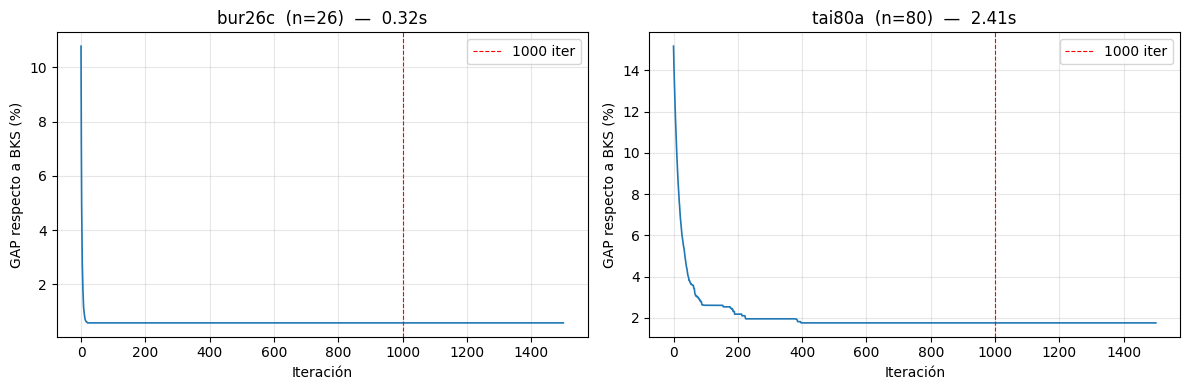

In [16]:
import matplotlib.pyplot as plt

MAX_ITER = 1500   # exploramos un poco más allá para ver si 1000 basta

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, ["bur26c", "tai80a"]):
    inst = load_instance(name)
    rng = np.random.default_rng(SEED_BASE)
    res = tabu_search_fast(inst, swap_full_deltas, rng, max_iter=MAX_ITER)

    hist = np.array(res.history)
    gap_hist = (hist - inst.bks) / inst.bks * 100

    ax.plot(gap_hist, lw=1.2)
    ax.axvline(1000, color="red", ls="--", lw=0.8, label="1000 iter")
    ax.set_title(f"{name}  (n={inst.n})  —  {res.elapsed:.2f}s")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("GAP respecto a BKS (%)")
    ax.legend()
    ax.grid(alpha=0.3)
    print(f"{name:8s}  GAP@1000={gap_hist[min(1000, len(gap_hist)-1)]:.3f}%   "
          f"GAP@final={gap_hist[-1]:.3f}%")

plt.tight_layout()
plt.show()

## Bloque 5e — Núcleo justo: presupuesto por evaluaciones de la función objetivo

**Igualar el esfuerzo computacional.** Para que la comparación entre operadores sea justa, todos deben ejecutar la función objetivo el mismo número de veces. Como cada iteración de la Búsqueda Tabú evalúa todo el vecindario, el número de evaluaciones por iteración es igual al tamaño del vecindario, que difiere entre operadores (la inserción tiene casi el doble de vecinos que el swap). Por eso fijar "misma cantidad de iteraciones" sería injusto. En su lugar, fijamos el presupuesto en NÚMERO DE EVALUACIONES de la función objetivo: cada operador corre hasta agotar el mismo presupuesto, haciendo más o menos iteraciones según su vecindario. Refactorizamos el núcleo para (1) contar las evaluaciones acumuladas, (2) detenerse al alcanzar el presupuesto, y (3) registrar el historial de convergencia indexado por evaluaciones (no por iteración), para que las curvas de los tres operadores sean directamente comparables. El núcleo queda parametrizado por dos funciones del operador: la que genera el vecindario (matriz de deltas + índices de los movimientos candidatos) y la que aplica un movimiento. Toda la mecánica tabú (lista, aspiración, tenencia) es idéntica para los tres, preservando el aislamiento del operador.

In [17]:
def apply_swap(perm: np.ndarray, r: int, s: int) -> np.ndarray:
    p = perm.copy()
    p[r], p[s] = p[s], p[r]
    return p


def swap_neighborhood(perm, F, D):
    """Devuelve (Delta, (cand_r, cand_s)) para el operador swap.
    Candidatos: pares r<s (vecindario simétrico, tamaño n(n-1)/2)."""
    n = len(perm)
    Delta = swap_full_deltas(perm, F, D)
    cand_r, cand_s = np.triu_indices(n, 1)
    return Delta, (cand_r, cand_s)


def tabu_search_fast(inst, neighborhood, apply_move, rng, eval_budget, tabu_tenure=None):
    """Búsqueda Tabú con presupuesto medido en EVALUACIONES de la función objetivo.
    Parametrizada por operador: neighborhood(perm,F,D)->(Delta,(cr,cs)) y apply_move(perm,r,s)."""
    n, F, D = inst.n, inst.F, inst.D
    if tabu_tenure is None:
        tabu_tenure = max(1, n // 2)

    perm = initial_solution(n, rng)
    cost = objective(perm, F, D)
    best_perm, best_cost = perm.copy(), cost

    tabu_until = np.zeros((n, n), dtype=np.int64)
    evals, it = 0, 0
    history = [(0, best_cost)]          # (evaluaciones acumuladas, mejor costo)
    t0 = time.perf_counter()

    while evals < eval_budget:
        it += 1
        Delta, (cand_r, cand_s) = neighborhood(perm, F, D)
        evals += cand_r.shape[0]        # tantas evaluaciones como candidatos del vecindario

        deltas = Delta[cand_r, cand_s]
        er, es = perm[cand_r], perm[cand_s]
        is_tabu   = tabu_until[er, es] >= it
        aspirated = (cost + deltas) < best_cost
        allowed   = (~is_tabu) | aspirated

        if not allowed.any():
            break

        cand = np.where(allowed, deltas, np.iinfo(np.int64).max)
        k = int(cand.argmin())
        r, s = int(cand_r[k]), int(cand_s[k])
        a, b = perm[r], perm[s]

        perm = apply_move(perm, r, s)
        cost += int(deltas[k])
        tabu_until[a, b] = tabu_until[b, a] = it + tabu_tenure

        if cost < best_cost:
            best_cost, best_perm = cost, perm.copy()
        history.append((evals, best_cost))

    return TSResult(best_perm, best_cost, history, it, time.perf_counter() - t0)


# --- Presupuesto: lo que el swap gastaría en 1000 iteraciones ---
ITER_REF = 1000
def eval_budget_for(n: int) -> int:
    return ITER_REF * (n * (n - 1) // 2)


# --- Sanity check: el swap con el núcleo nuevo debe reproducir los GAP anteriores ---
for name in ["bur26c", "tai80a"]:
    inst = load_instance(name)
    rng = np.random.default_rng(SEED_BASE)
    budget = eval_budget_for(inst.n)
    res = tabu_search_fast(inst, swap_neighborhood, apply_swap, rng, budget)
    gap = (res.best_cost - inst.bks) / inst.bks * 100
    print(f"{name:8s}  swap  {res.iterations} iter / {budget:,} evals  ->  "
          f"{res.elapsed:.2f}s   GAP={gap:.3f}%")

bur26c    swap  1000 iter / 325,000 evals  ->  0.30s   GAP=0.582%
tai80a    swap  1000 iter / 3,160,000 evals  ->  1.73s   GAP=1.763%


## Bloque 6 — Operadores con evaluación delta compilada (Numba)

**Justicia de tiempo: misma técnica para todos.** El swap se podía vectorizar con productos de matrices, pero la inserción no admite esa forma cerrada porque el desplazamiento mueve las posiciones y rompe la estructura matricial. Para que la comparación de tiempo sea justa, implementamos los tres operadores con una misma técnica: calcular el delta O(n) por movimiento dentro de un bucle compilado con Numba (njit), que traduce el código a lenguaje máquina y elimina el overhead del intérprete de Python (la causa real de la lentitud anterior). Definimos una función base compilada para el delta de un intercambio de posiciones cualquiera, y sobre ella construimos: (1) el vecindario de swap, y (2) el de inserción, que se obtiene deslizando el elemento mediante intercambios adyacentes y acumulando sus deltas. Validamos el swap compilado contra la versión matricial (que ya confiábamos) y la inserción contra la función objetivo. La primera ejecución compila (tarda unos segundos una sola vez); las siguientes son muy rápidas.

In [24]:
try:
    from numba import njit
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numba"])
    from numba import njit


@njit(cache=True)
def _swap_delta_nb(perm, F, D, r, s):
    """Delta O(n) de intercambiar las posiciones r, s (caso general). Compilado."""
    n = perm.shape[0]
    a = perm[r]; b = perm[s]
    delta = 0
    for k in range(n):
        if k == r or k == s:
            continue
        pk = perm[k]
        delta += (F[r, k] * (D[b, pk] - D[a, pk]) + F[s, k] * (D[a, pk] - D[b, pk])
                  + F[k, r] * (D[pk, b] - D[pk, a]) + F[k, s] * (D[pk, a] - D[pk, b]))
    delta += (F[r, s] * (D[b, a] - D[a, b]) + F[s, r] * (D[a, b] - D[b, a])
              + F[r, r] * (D[b, b] - D[a, a]) + F[s, s] * (D[a, a] - D[b, b]))
    return delta


@njit(cache=True)
def swap_full_deltas_nb(perm, F, D):
    """Matriz n x n de deltas de swap (compilada)."""
    n = perm.shape[0]
    Delta = np.zeros((n, n), dtype=np.int64)
    for r in range(n - 1):
        for s in range(r + 1, n):
            d = _swap_delta_nb(perm, F, D, r, s)
            Delta[r, s] = d
            Delta[s, r] = d
    return Delta


@njit(cache=True)
def insertion_full_deltas_nb(perm, F, D):
    """Matriz n x n de deltas de inserción vía intercambios adyacentes acumulados (compilada)."""
    n = perm.shape[0]
    Delta = np.zeros((n, n), dtype=np.int64)
    for r in range(n):
        # ---- hacia la derecha: r -> r+1 -> ... -> n-1 ----
        work = perm.copy()
        acc = 0
        for s in range(r, n - 1):
            acc += _swap_delta_nb(work, F, D, s, s + 1)
            tmp = work[s]; work[s] = work[s + 1]; work[s + 1] = tmp
            Delta[r, s + 1] = acc
        # ---- hacia la izquierda: r -> r-1 -> ... -> 0 ----
        work = perm.copy()
        acc = 0
        for s in range(r, 0, -1):
            acc += _swap_delta_nb(work, F, D, s, s - 1)
            tmp = work[s]; work[s] = work[s - 1]; work[s - 1] = tmp
            Delta[r, s - 1] = acc
    return Delta


# --- Envoltorios para tabu_search_fast (Delta + índices de candidatos) ---
def swap_neighborhood(perm, F, D):
    n = len(perm)
    Delta = swap_full_deltas_nb(perm, F, D)
    cr, cs = np.triu_indices(n, 1)
    return Delta, (cr, cs)

def insertion_neighborhood(perm, F, D):
    n = len(perm)
    Delta = insertion_full_deltas_nb(perm, F, D)
    rr, ss = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    mask = rr != ss
    return Delta, (rr[mask], ss[mask])

def apply_insertion(perm, r, s):
    val = perm[r]
    rest = np.delete(perm, r)
    return np.insert(rest, s, val)


# --- 1) Validar swap compilado contra la versión matricial (confiable) ---
inst = load_instance("bur26c")
rng = np.random.default_rng(SEED_BASE)
perm = rng.permutation(inst.n)
ok_swap = np.array_equal(swap_full_deltas_nb(perm, inst.F, inst.D),
                         swap_full_deltas(perm, inst.F, inst.D))
print("✓ swap_full_deltas_nb == swap_full_deltas (matricial)" if ok_swap else "✗ revisar swap nb")

# --- 2) Validar inserción compilada contra la función objetivo ---
Delta = insertion_full_deltas_nb(perm, inst.F, inst.D)
base = objective(perm, inst.F, inst.D)
ok_ins = True
for r in range(inst.n):
    for s in range(inst.n):
        if r == s:
            continue
        if int(Delta[r, s]) != objective(apply_insertion(perm, r, s), inst.F, inst.D) - base:
            ok_ins = False; print(f"✗ inserción discrepa en ({r},{s})"); break
    if not ok_ins:
        break
print("✓ insertion_full_deltas_nb validado contra la objetivo" if ok_ins else "✗ revisar inserción nb")


# --- 3) Tiempo + calidad de ambos operadores bajo presupuesto justo ---
print("\n--- Resultados (presupuesto justo en evaluaciones) ---")
for op_name, neigh, apply_fn in [("swap", swap_neighborhood, apply_swap),
                                 ("inserción", insertion_neighborhood, apply_insertion)]:
    for name in ["bur26c", "tai80a"]:
        inst = load_instance(name)
        rng = np.random.default_rng(SEED_BASE)
        budget = eval_budget_for(inst.n)
        res = tabu_search_fast(inst, neigh, apply_fn, rng, budget)
        gap = (res.best_cost - inst.bks) / inst.bks * 100
        print(f"{op_name:10s} {name:8s}  {res.iterations:4d} iter  ->  "
              f"{res.elapsed:6.2f}s   GAP={gap:.3f}%")

✓ swap_full_deltas_nb == swap_full_deltas (matricial)
✓ insertion_full_deltas_nb validado contra la objetivo

--- Resultados (presupuesto justo en evaluaciones) ---
swap       bur26c    1000 iter  ->    0.15s   GAP=0.582%
swap       tai80a    1000 iter  ->    2.23s   GAP=1.763%
inserción  bur26c     500 iter  ->    0.36s   GAP=1.225%
inserción  tai80a     500 iter  ->    3.00s   GAP=8.051%


## Bloque 7 — Operador de inversión (2-opt), con delta compilado

**El tercer vecindario.** La inversión (2-opt) toma un segmento contiguo de la permutación, entre las posiciones r y s, y lo invierte (lo da vuelta). Es el movimiento clásico del 2-opt en problemas de rutas; en el QAP define un vecindario válido aunque no exista una estructura de ruta subyacente, lo que lo vuelve un operador menos convencional e interesante de contrastar. Su vecindario tiene n(n-1)/2 movimientos, igual que el swap (un par r<s por cada segmento posible). Implementamos su delta con la misma técnica que los otros operadores: como invertir el segmento [r, s] equivale a una secuencia de intercambios de los extremos hacia el centro, calculamos el delta acumulando esos swaps, todo dentro de una función compilada con Numba para que el tiempo sea comparable. Validamos contra la diferencia real de la función objetivo. Se conecta a la misma tabu_search_fast, completando los tres operadores bajo idéntica mecánica tabú e idéntico paradigma de implementación.

In [25]:
def apply_inversion(perm, r, s):
    """Invierte el segmento contiguo [r, s] (r < s)."""
    p = perm.copy()
    p[r:s + 1] = p[r:s + 1][::-1]
    return p


@njit(cache=True)
def insertion_segment_inversion_delta(perm, F, D, r, s):
    """Delta O((s-r)*n) de invertir el segmento [r, s], acumulando swaps de extremos.
    Invertir [r,s] = intercambiar (r,s), (r+1,s-1), ... trabajando hacia el centro,
    sobre una permutación que se va actualizando."""
    work = perm.copy()
    acc = 0
    i = r; j = s
    while i < j:
        acc += _swap_delta_nb(work, F, D, i, j)
        tmp = work[i]; work[i] = work[j]; work[j] = tmp
        i += 1; j -= 1
    return acc


@njit(cache=True)
def inversion_full_deltas_nb(perm, F, D):
    """Matriz n x n de deltas de inversión (compilada). Delta[r,s] = invertir [r,s], r<s."""
    n = perm.shape[0]
    Delta = np.zeros((n, n), dtype=np.int64)
    for r in range(n - 1):
        for s in range(r + 1, n):
            Delta[r, s] = insertion_segment_inversion_delta(perm, F, D, r, s)
            Delta[s, r] = Delta[r, s]
    return Delta


def inversion_neighborhood(perm, F, D):
    n = len(perm)
    Delta = inversion_full_deltas_nb(perm, F, D)
    cr, cs = np.triu_indices(n, 1)
    return Delta, (cr, cs)


# --- Validación contra la diferencia real de la función objetivo ---
inst = load_instance("bur26c")
rng = np.random.default_rng(SEED_BASE)
perm = rng.permutation(inst.n)
Delta = inversion_full_deltas_nb(perm, inst.F, inst.D)
base = objective(perm, inst.F, inst.D)

ok = True
for r in range(inst.n - 1):
    for s in range(r + 1, inst.n):
        if int(Delta[r, s]) != objective(apply_inversion(perm, r, s), inst.F, inst.D) - base:
            ok = False; print(f"✗ inversión discrepa en ({r},{s})"); break
    if not ok:
        break
print("✓ inversion_full_deltas_nb validado contra la objetivo" if ok else "✗ revisar inversión")


# --- Tiempo + calidad bajo presupuesto justo ---
print("\n--- Inversión (presupuesto justo en evaluaciones) ---")
for name in ["bur26c", "tai80a"]:
    inst = load_instance(name)
    rng = np.random.default_rng(SEED_BASE)
    budget = eval_budget_for(inst.n)
    res = tabu_search_fast(inst, inversion_neighborhood, apply_inversion, rng, budget)
    gap = (res.best_cost - inst.bks) / inst.bks * 100
    print(f"inversión  {name:8s}  {res.iterations:4d} iter  ->  {res.elapsed:6.2f}s   GAP={gap:.3f}%")

✓ inversion_full_deltas_nb validado contra la objetivo

--- Inversión (presupuesto justo en evaluaciones) ---
inversión  bur26c    1000 iter  ->    0.43s   GAP=1.005%
inversión  tai80a    1000 iter  ->   28.01s   GAP=6.851%
